#!/usr/bin/env python3

"""
Reproduce: "Phylum-level retention (top 15 phyla by total read signal)" grouped bar plot.

Input:
  A CSV export of the printed per-sample phylum table (like your file):
    Bin_phylum - Sheet1 (1).csv

Output:
  fig_phylum_retention_top15.png

What it does:
1) Parses rows into a tidy table: (sample, phylum, read_count, contig_p, bin_p)
2) Ranks phyla by TOTAL read_count summed across samples
3) Takes top N=15 phyla
4) Plots MEDIAN retention vs reads (%) for contigs and MAGs per phylum
"""

In [2]:
!pwd

/group/ctbrowngrp4/2025-zyzhao-assemloss/binning/notebook


In [3]:
# conda install -c conda-forge plotly

In [1]:
import re
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import taxburst.checks

... 0/915
... 50/915
... 100/915
... 150/915
... 200/915
... 250/915
... 300/915
... 350/915
... 400/915
... 450/915
... 500/915
... 550/915
... 600/915
... 650/915
... 700/915
... 750/915
... 800/915
... 850/915
... 900/915
Built table: 45743 rows
Saved: phylum_retention_top8.png


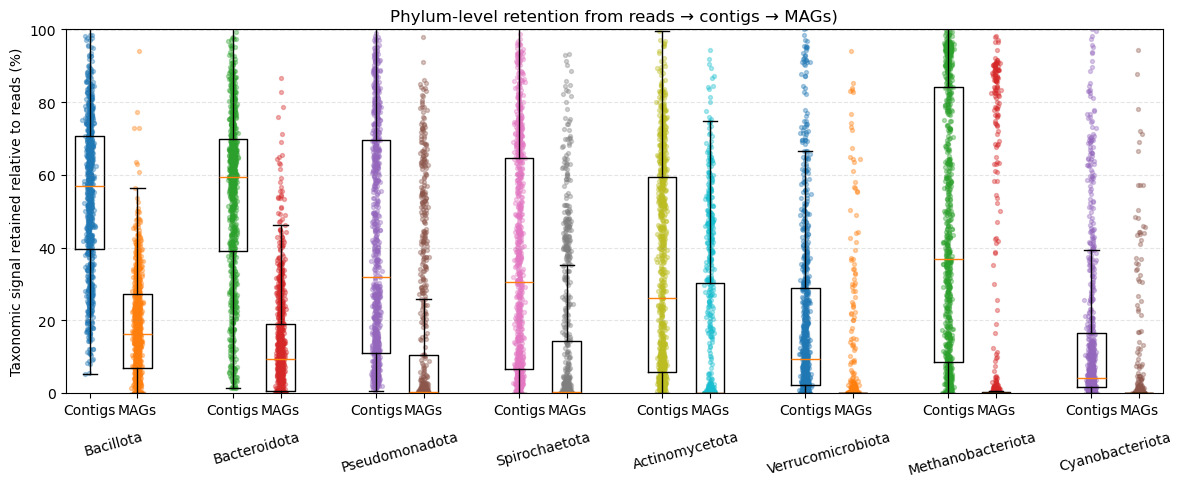

In [5]:
# -------------------------
# CONFIG
# -------------------------
ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
SAMPLE_LIST = os.path.join(ROOT, "SAMPLE-LIST.BIG.txt")
TAX_DIR = os.path.join(ROOT, "outputs", "tax")

RANK = "phylum"
TOP_N_PHYLA = 8

OUTFIG = "phylum_retention_top8.png"
SEED = 0

# -------------------------
# FUNCTIONS
# -------------------------
def extract_nodes_by_rank_and_name(tree):

    nodes = taxburst.checks.collect_all_nodes(tree)

    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}

    for node in nodes:

        rank = node.get("rank")
        name = node.get("name")

        if rank is None or name is None:
            continue

        nodes_by_rank[rank].append(node)

        if name not in nodes_by_name:
            nodes_by_name[name] = node

    return nodes_by_rank, nodes_by_name

def load_tree(path):

    with open(path) as fp:
        return json.load(fp)
# -------------------------
# MAIN
# -------------------------
def main():

    with open(SAMPLE_LIST) as fp:
        samples = [x.strip() for x in fp if x.strip()]

    rows = []
    missing = 0

    for i, sample in enumerate(samples):

        if i % 50 == 0:
            print(f"... {i}/{len(samples)}")

        reads_path = os.path.join(TAX_DIR, f"{sample}.reads.gather.json")
        contigs_path = os.path.join(TAX_DIR, f"{sample}.contigs.gather.json")
        bins_path = os.path.join(TAX_DIR, f"{sample}.bins.gather.json")

        if not (
            os.path.exists(reads_path)
            and os.path.exists(contigs_path)
            and os.path.exists(bins_path)
        ):
            missing += 1
            continue

        read_tree = load_tree(reads_path)
        contig_tree = load_tree(contigs_path)
        bin_tree = load_tree(bins_path)

        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)

        for read_node in read_by_rank.get(RANK, []):

            name = read_node.get("name")

            if name in (None, "unclassified"):
                continue

            read_count = float(read_node.get("count", 0))

            if read_count <= 0:
                continue

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = float(contig_node.get("count", 0)) if contig_node else 0
            bin_count = float(bin_node.get("count", 0)) if bin_node else 0

            rows.append(
                dict(
                    sample=sample,
                    taxon=name,
                    read_count=read_count,
                    contig_count=contig_count,
                    bin_count=bin_count,
                    contig_p=contig_count / read_count * 100,
                    bin_p=bin_count / read_count * 100,
                )
            )

    df = pd.DataFrame(rows)

    if df.empty:
        raise SystemExit("No data loaded")

    print(f"Built table: {df.shape[0]} rows")

    # -------------------------
    # Top phyla
    # -------------------------
    top_phyla = (
        df.groupby("taxon")["read_count"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N_PHYLA)
        .index
        .tolist()
    )

    df = df[df["taxon"].isin(top_phyla)]

    # -------------------------
    # Prepare plot data
    # -------------------------
    contig_data = []
    mag_data = []

    for taxon in top_phyla:

        contig_vals = df.loc[df.taxon == taxon, "contig_p"].to_numpy()
        mag_vals = df.loc[df.taxon == taxon, "bin_p"].to_numpy()

        contig_data.append(contig_vals)
        mag_data.append(mag_vals)

    rng = np.random.default_rng(SEED)

    # -------------------------
    # POSITIONING
    # -------------------------
    n = len(top_phyla)

    group_spacing = 3.0
    offset = 0.5

    centers = np.arange(n) * group_spacing

    contig_pos = centers - offset
    mag_pos = centers + offset

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.boxplot(contig_data, positions=contig_pos, widths=0.6, showfliers=False)
    ax.boxplot(mag_data, positions=mag_pos, widths=0.6, showfliers=False)

    # jitter points
    for i in range(n):

        x = rng.normal(contig_pos[i], 0.04, size=len(contig_data[i]))
        ax.scatter(x, contig_data[i], s=8, alpha=0.35)

        x = rng.normal(mag_pos[i], 0.04, size=len(mag_data[i]))
        ax.scatter(x, mag_data[i], s=8, alpha=0.35)

    ax.axhline(100, linestyle="--", color="gray", linewidth=1)

    # x labels
    xticks = []
    xlabels = []

    for i in range(n):
        xticks.extend([contig_pos[i], mag_pos[i]])
        xlabels.extend(["Contigs", "MAGs"])

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

    # phylum labels
    for i, taxon in enumerate(top_phyla):

        ax.text(
            centers[i],
            -10,
            taxon.replace("p__", ""),
            ha="center",
            va="top",
            rotation=15,
        )

    ax.set_ylabel("Taxonomic signal retained relative to reads (%)")
    ax.set_ylim(0, 100)

    for y in [20, 40, 60, 80]:
        ax.axhline(y, linestyle="--", linewidth=0.8, color="gray", alpha=0.2 )
    
    ax.set_title("Phylum-level retention from reads → contigs → MAGs)")
    
    plt.tight_layout()
    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")

    print("Saved:", OUTFIG)

if __name__ == "__main__":
    main()

... 0/915
... 50/915
... 100/915
... 150/915
... 200/915
... 250/915
... 300/915
... 350/915
... 400/915
... 450/915
... 500/915
... 550/915
... 600/915
... 650/915
... 700/915
... 750/915
... 800/915
... 850/915
... 900/915
Built table: 45743 rows
Saved: phylum_retention_top8.png


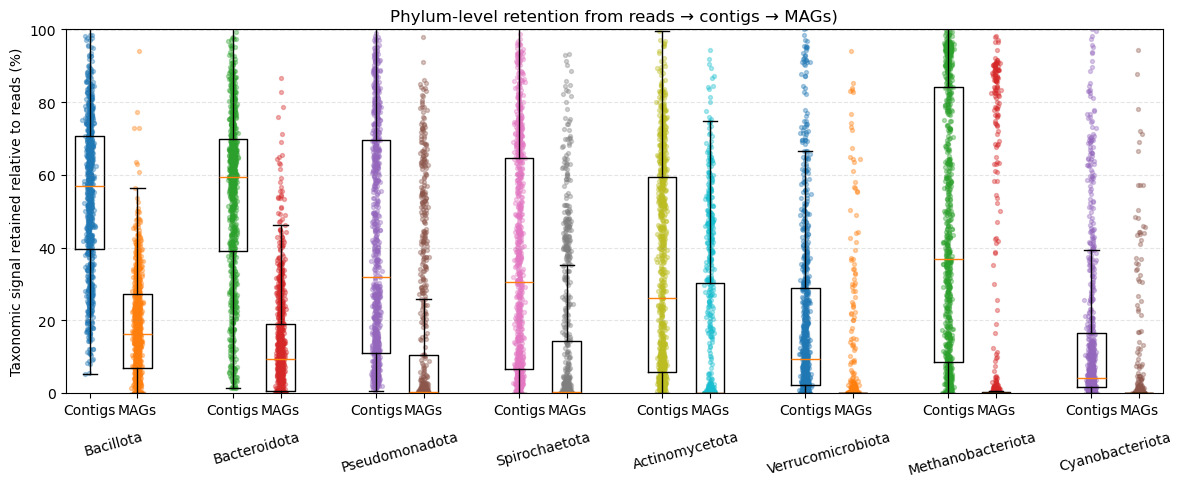

In [5]:
# -------------------------
# CONFIG
# -------------------------
ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
SAMPLE_LIST = os.path.join(ROOT, "SAMPLE-LIST.BIG.txt")
TAX_DIR = os.path.join(ROOT, "outputs", "tax")

RANK = "phylum"
TOP_N_PHYLA = 8

OUTFIG = "phylum_retention_top8.png"
SEED = 0

# -------------------------
# FUNCTIONS
# -------------------------
def extract_nodes_by_rank_and_name(tree):

    nodes = taxburst.checks.collect_all_nodes(tree)

    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}

    for node in nodes:

        rank = node.get("rank")
        name = node.get("name")

        if rank is None or name is None:
            continue

        nodes_by_rank[rank].append(node)

        if name not in nodes_by_name:
            nodes_by_name[name] = node

    return nodes_by_rank, nodes_by_name

def load_tree(path):

    with open(path) as fp:
        return json.load(fp)
# -------------------------
# MAIN
# -------------------------
def main():

    with open(SAMPLE_LIST) as fp:
        samples = [x.strip() for x in fp if x.strip()]

    rows = []
    missing = 0

    for i, sample in enumerate(samples):

        if i % 50 == 0:
            print(f"... {i}/{len(samples)}")

        reads_path = os.path.join(TAX_DIR, f"{sample}.reads.gather.json")
        contigs_path = os.path.join(TAX_DIR, f"{sample}.contigs.gather.json")
        bins_path = os.path.join(TAX_DIR, f"{sample}.bins.gather.json")

        if not (
            os.path.exists(reads_path)
            and os.path.exists(contigs_path)
            and os.path.exists(bins_path)
        ):
            missing += 1
            continue

        read_tree = load_tree(reads_path)
        contig_tree = load_tree(contigs_path)
        bin_tree = load_tree(bins_path)

        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)

        for read_node in read_by_rank.get(RANK, []):

            name = read_node.get("name")

            if name in (None, "unclassified"):
                continue

            read_count = float(read_node.get("count", 0))

            if read_count <= 0:
                continue

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = float(contig_node.get("count", 0)) if contig_node else 0
            bin_count = float(bin_node.get("count", 0)) if bin_node else 0

            rows.append(
                dict(
                    sample=sample,
                    taxon=name,
                    read_count=read_count,
                    contig_count=contig_count,
                    bin_count=bin_count,
                    contig_p=contig_count / read_count * 100,
                    bin_p=bin_count / read_count * 100,
                )
            )

    df = pd.DataFrame(rows)

    if df.empty:
        raise SystemExit("No data loaded")

    print(f"Built table: {df.shape[0]} rows")

    # -------------------------
    # Top phyla
    # -------------------------
    top_phyla = (
        df.groupby("taxon")["read_count"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N_PHYLA)
        .index
        .tolist()
    )

    df = df[df["taxon"].isin(top_phyla)]

    # -------------------------
    # Prepare plot data
    # -------------------------
    contig_data = []
    mag_data = []

    for taxon in top_phyla:

        contig_vals = df.loc[df.taxon == taxon, "contig_p"].to_numpy()
        mag_vals = df.loc[df.taxon == taxon, "bin_p"].to_numpy()

        contig_data.append(contig_vals)
        mag_data.append(mag_vals)

    rng = np.random.default_rng(SEED)

    # -------------------------
    # POSITIONING
    # -------------------------
    n = len(top_phyla)

    group_spacing = 3.0
    offset = 0.5

    centers = np.arange(n) * group_spacing

    contig_pos = centers - offset
    mag_pos = centers + offset

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.boxplot(contig_data, positions=contig_pos, widths=0.6, showfliers=False)
    ax.boxplot(mag_data, positions=mag_pos, widths=0.6, showfliers=False)

    # jitter points
    for i in range(n):

        x = rng.normal(contig_pos[i], 0.04, size=len(contig_data[i]))
        ax.scatter(x, contig_data[i], s=8, alpha=0.35)

        x = rng.normal(mag_pos[i], 0.04, size=len(mag_data[i]))
        ax.scatter(x, mag_data[i], s=8, alpha=0.35)

    ax.axhline(100, linestyle="--", color="gray", linewidth=1)

    # x labels
    xticks = []
    xlabels = []

    for i in range(n):
        xticks.extend([contig_pos[i], mag_pos[i]])
        xlabels.extend(["Contigs", "MAGs"])

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

    # phylum labels
    for i, taxon in enumerate(top_phyla):

        ax.text(
            centers[i],
            -10,
            taxon.replace("p__", ""),
            ha="center",
            va="top",
            rotation=15,
        )

    ax.set_ylabel("Taxonomic signal retained relative to reads (%)")
    ax.set_ylim(0, 100)

    for y in [20, 40, 60, 80]:
        ax.axhline(y, linestyle="--", linewidth=0.8, color="gray", alpha=0.2 )
    
    ax.set_title("Phylum-level retention from reads → contigs → MAGs)")
    
    plt.tight_layout()
    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")

    print("Saved:", OUTFIG)

if __name__ == "__main__":
    main()

... 0/915
... 50/915
... 100/915
... 150/915
... 200/915
... 250/915
... 300/915
... 350/915
... 400/915
... 450/915
... 500/915
... 550/915
... 600/915
... 650/915
... 700/915
... 750/915
... 800/915
... 850/915
... 900/915
Built table: 45743 rows
Saved: phylum_retention_top8.png


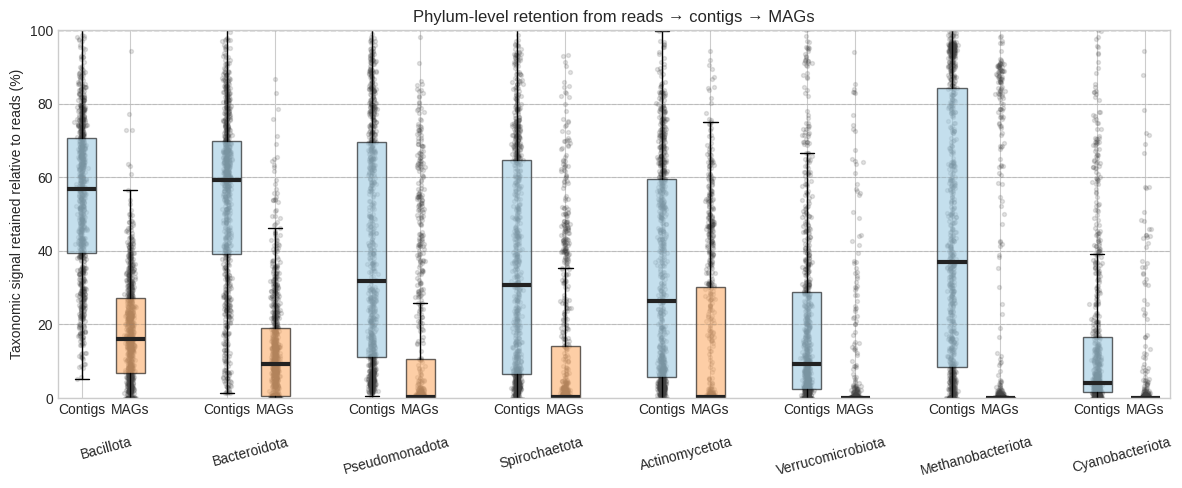

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import taxburst

# -------------------------
# CONFIG
# -------------------------
ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
SAMPLE_LIST = os.path.join(ROOT, "SAMPLE-LIST.BIG.txt")
TAX_DIR = os.path.join(ROOT, "outputs", "tax")

RANK = "phylum"
TOP_N_PHYLA = 8

OUTFIG = "phylum_retention_top8.png"
SEED = 0


# -------------------------
# FUNCTIONS
# -------------------------
def extract_nodes_by_rank_and_name(tree):

    nodes = taxburst.checks.collect_all_nodes(tree)

    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}

    for node in nodes:

        rank = node.get("rank")
        name = node.get("name")

        if rank is None or name is None:
            continue

        nodes_by_rank[rank].append(node)

        if name not in nodes_by_name:
            nodes_by_name[name] = node

    return nodes_by_rank, nodes_by_name


def load_tree(path):
    with open(path) as fp:
        return json.load(fp)


# -------------------------
# MAIN
# -------------------------
def main():

    with open(SAMPLE_LIST) as fp:
        samples = [x.strip() for x in fp if x.strip()]

    rows = []
    missing = 0

    for i, sample in enumerate(samples):

        if i % 50 == 0:
            print(f"... {i}/{len(samples)}")

        reads_path = os.path.join(TAX_DIR, f"{sample}.reads.gather.json")
        contigs_path = os.path.join(TAX_DIR, f"{sample}.contigs.gather.json")
        bins_path = os.path.join(TAX_DIR, f"{sample}.bins.gather.json")

        if not (
            os.path.exists(reads_path)
            and os.path.exists(contigs_path)
            and os.path.exists(bins_path)
        ):
            missing += 1
            continue

        read_tree = load_tree(reads_path)
        contig_tree = load_tree(contigs_path)
        bin_tree = load_tree(bins_path)

        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)

        for read_node in read_by_rank.get(RANK, []):

            name = read_node.get("name")

            if name in (None, "unclassified"):
                continue

            read_count = float(read_node.get("count", 0))
            if read_count <= 0:
                continue

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = float(contig_node.get("count", 0)) if contig_node else 0
            bin_count = float(bin_node.get("count", 0)) if bin_node else 0

            rows.append(
                dict(
                    sample=sample,
                    taxon=name,
                    read_count=read_count,
                    contig_p=contig_count / read_count * 100,
                    bin_p=bin_count / read_count * 100,
                )
            )

    df = pd.DataFrame(rows)

    if df.empty:
        raise SystemExit("No data loaded")

    print(f"Built table: {df.shape[0]} rows")

    # -------------------------
    # Top phyla
    # -------------------------
    top_phyla = (
        df.groupby("taxon")["read_count"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N_PHYLA)
        .index
        .tolist()
    )

    df = df[df["taxon"].isin(top_phyla)]

    # -------------------------
    # Prepare plot data
    # -------------------------
    contig_data = []
    mag_data = []

    for taxon in top_phyla:

        contig_vals = df.loc[df.taxon == taxon, "contig_p"].to_numpy()
        mag_vals = df.loc[df.taxon == taxon, "bin_p"].to_numpy()

        contig_data.append(contig_vals)
        mag_data.append(mag_vals)

    rng = np.random.default_rng(SEED)

    # -------------------------
    # POSITIONING
    # -------------------------
    n = len(top_phyla)

    group_spacing = 3.0
    offset = 0.5

    centers = np.arange(n) * group_spacing

    contig_pos = centers - offset
    mag_pos = centers + offset

    # -------------------------
    # Plot
    # -------------------------
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, ax = plt.subplots(figsize=(12, 5))

    # Boxplots with strong medians
    ax.boxplot(
        contig_data,
        positions=contig_pos,
        widths=0.6,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor="#9ecae1", alpha=0.6),
        medianprops=dict(color="#222222", linewidth=3),
    )

    ax.boxplot(
        mag_data,
        positions=mag_pos,
        widths=0.6,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor="#fdae6b", alpha=0.6),
        medianprops=dict(color="#222222", linewidth=3),
    )

    # Jitter points (lighter so median is visible)
    for i in range(n):

        x = rng.normal(contig_pos[i], 0.04, size=len(contig_data[i]))
        ax.scatter(x, contig_data[i], s=8, alpha=0.15, color="#444444")

        x = rng.normal(mag_pos[i], 0.04, size=len(mag_data[i]))
        ax.scatter(x, mag_data[i], s=8, alpha=0.15, color="#444444")

    ax.axhline(100, linestyle="--", color="gray", linewidth=1)

    # x labels
    xticks = []
    xlabels = []

    for i in range(n):
        xticks.extend([contig_pos[i], mag_pos[i]])
        xlabels.extend(["Contigs", "MAGs"])

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

    # phylum labels
    for i, taxon in enumerate(top_phyla):

        ax.text(
            centers[i],
            -10,
            taxon.replace("p__", ""),
            ha="center",
            va="top",
            rotation=15,
        )

    ax.set_ylabel("Taxonomic signal retained relative to reads (%)")
    ax.set_ylim(0, 100)

    # subtle grid
    for y in [20, 40, 60, 80]:
        ax.axhline(y, linestyle="--", linewidth=0.8, color="gray", alpha=0.2)

    ax.set_title("Phylum-level retention from reads → contigs → MAGs")

    plt.tight_layout()
    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")

    print("Saved:", OUTFIG)


if __name__ == "__main__":
    main()


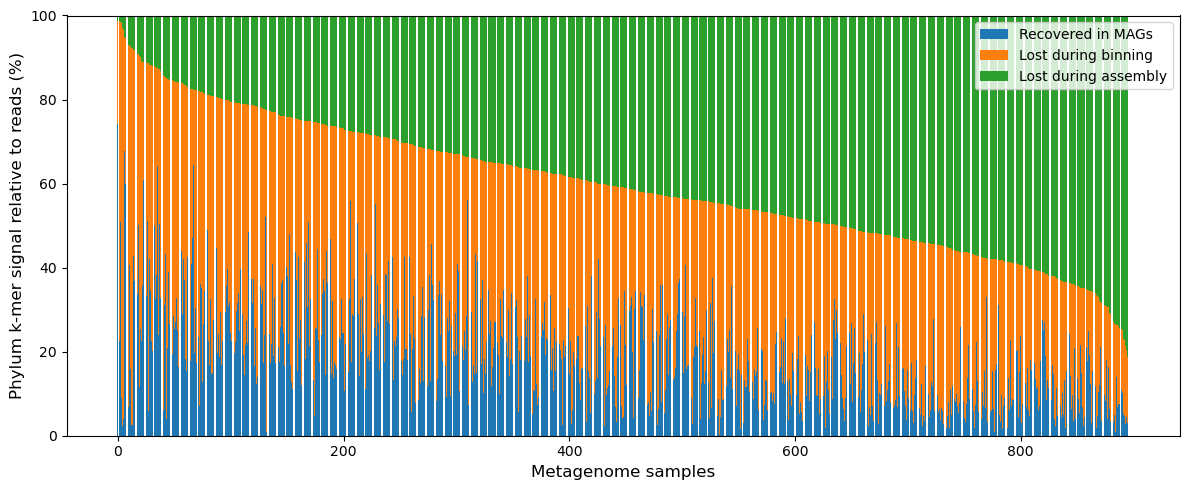

In [30]:
## bar fig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("phylum_retention.tsv", sep="\t")

# -------------------------
# compute totals per sample
# -------------------------
sample_sum = (
    df.groupby("sample")[["read_count","contig_count","bin_count"]]
    .sum()
    .reset_index()
)

# retention
sample_sum["contig_retention"] = sample_sum["contig_count"] / sample_sum["read_count"] * 100
sample_sum["mag_retention"] = sample_sum["bin_count"] / sample_sum["read_count"] * 100

# losses
sample_sum["assembly_loss"] = 100 - sample_sum["contig_retention"]
sample_sum["binning_loss"] = sample_sum["contig_retention"] - sample_sum["mag_retention"]

# -------------------------
# sort samples
# -------------------------
sample_sum = sample_sum.sort_values("contig_retention", ascending=False)

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(12,5))

x = np.arange(len(sample_sum))

ax.bar(x, sample_sum["mag_retention"], label="Recovered in MAGs")
ax.bar(x, sample_sum["binning_loss"],
       bottom=sample_sum["mag_retention"],
       label="Lost during binning")

ax.bar(x, sample_sum["assembly_loss"],
       bottom=sample_sum["contig_retention"],
       label="Lost during assembly")

ax.set_ylabel("Phylum k-mer signal relative to reads (%)",fontsize=12)
ax.set_xlabel("Metagenome samples",fontsize=12)
ax.set_ylim(0,100)

ax.legend()

plt.tight_layout()
plt.show()

Rows: 45743
Samples: 897
Phyla: 186
Top phyla: ['p__Bacillota', 'p__Bacteroidota', 'p__Pseudomonadota', 'p__Spirochaetota', 'p__Actinomycetota', 'p__Verrucomicrobiota', 'p__Methanobacteriota', 'p__Cyanobacteriota']


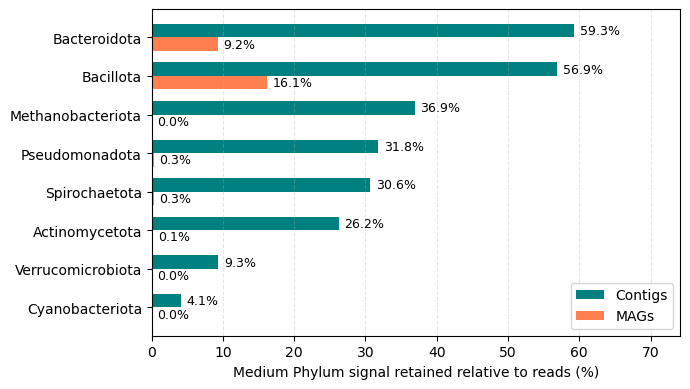

Saved: phylum_retention_bar.png


In [26]:
## bar fig median
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT = "phylum_retention.tsv"
TOP_N_PHYLA = 8
OUTFIG = "phylum_retention_bar.png"

df = pd.read_csv(INPUT, sep="\t")
print("Rows:", len(df))
print("Samples:", df["sample"].nunique())
print("Phyla:", df["phylum"].nunique())
df = df[df["phylum"] != "unclassified"]
# -------------------------
# determine top phyla
# -------------------------
top_phyla = (
    df.groupby("phylum")["read_count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_PHYLA)
    .index
    .tolist()
)
print("Top phyla:", top_phyla)

# keep only top phyla
df = df[df["phylum"].isin(top_phyla)]

# -------------------------
# compute medians
# -------------------------
contig_med = []
mag_med = []

for phylum in top_phyla:
    contig_vals = df.loc[df.phylum == phylum, "contig_percent"].values
    mag_vals = df.loc[df.phylum == phylum, "bin_percent"].values

    contig_med.append(np.median(contig_vals))
    mag_med.append(np.median(mag_vals))

labels = [p.replace("p__", "") for p in top_phyla]
# -------------------------
# sort by contig retention
# -------------------------
order = np.argsort(contig_med)[::-1]

labels = np.array(labels)[order]
contig_med = np.array(contig_med)[order]
mag_med = np.array(mag_med)[order]

y = np.arange(len(labels))
h = 0.35
contig_color = "#008080"   # blue
mag_color = "#FF7F50"      # orange

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(7,4))

bars1 = ax.barh(y - h/2, contig_med, height=h, color=contig_color, label="Contigs")
bars2 = ax.barh(y + h/2,mag_med,height=h,color=mag_color,label="MAGs")
# -------------------------
# add % labels
# -------------------------
for bar in bars1:
    w = bar.get_width()
    ax.text(w + 0.8,bar.get_y() + bar.get_height()/2,f"{w:.1f}%",va="center",fontsize=9)

for bar in bars2:
    w = bar.get_width()
    ax.text(w + 0.8,bar.get_y() + bar.get_height()/2,f"{w:.1f}%",va="center",fontsize=9)
# -------------------------
# axis formatting
# -------------------------
ax.set_yticks(y)
ax.set_yticklabels(labels)

# dynamic x limit
max_val = max(contig_med.max(), mag_med.max())
ax.set_xlim(0, max_val * 1.25)
ax.set_xlabel("Medium Phylum signal retained relative to reads (%)")

# light grid
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend()
#ax.set_title("Phylum-level retention from reads → contigs → MAGs")

# invert so best phylum is on top
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTFIG, bbox_inches="tight")

plt.show()
print("Saved:", OUTFIG)

In [15]:
## add median of loss from contigs to bins

Loaded 915 samples
... 0/915
... 50/915
... 100/915
... 150/915
... 200/915
... 250/915
... 300/915
... 350/915
... 400/915
... 450/915
... 500/915
... 550/915
... 600/915
... 650/915
... 700/915
... 750/915
... 800/915
... 850/915
... 900/915
Built table: 45743 rows across 897 samples
Missing samples skipped: 18
Top phyla: ['p__Bacillota', 'p__Bacteroidota', 'p__Pseudomonadota', 'p__Spirochaetota', 'p__Actinomycetota', 'p__Verrucomicrobiota', 'p__Methanobacteriota', 'p__Cyanobacteriota']
Saved: fig_phylum_retention.png


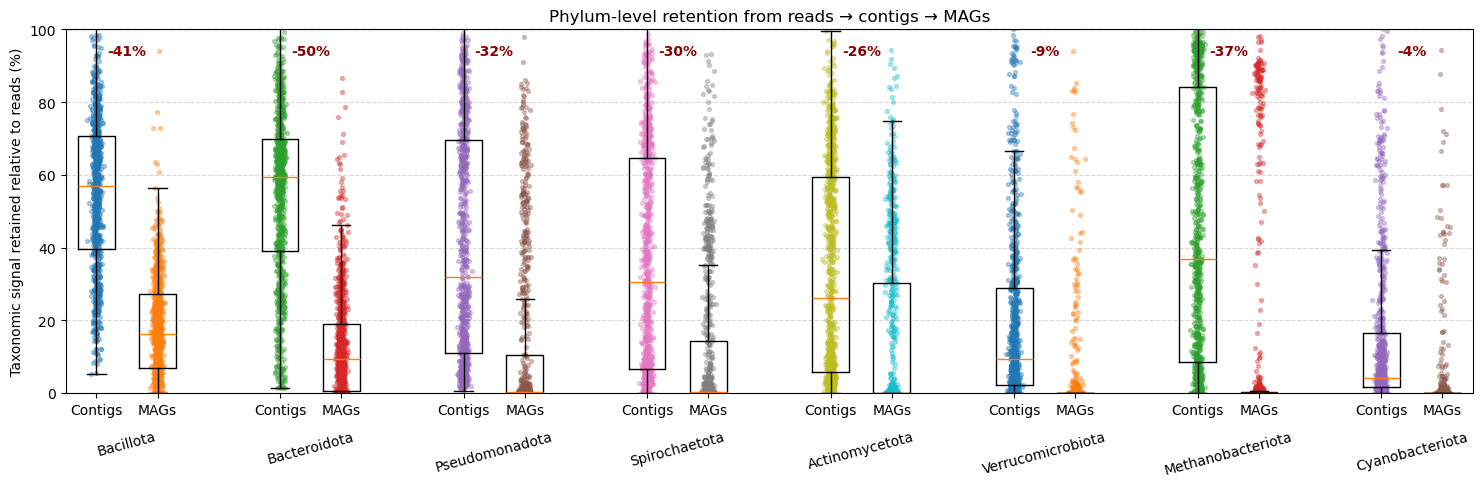

In [12]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import taxburst

# -------------------------
# CONFIG
# -------------------------
ROOT = "/home/ctbrown/scratch3/2025-jean-binning-loss/"
SAMPLE_LIST = os.path.join(ROOT, "SAMPLE-LIST.BIG.txt")
TAX_DIR = os.path.join(ROOT, "outputs", "tax")

RANK = "phylum"
TOP_N_PHYLA = 8

OUTFIG = "fig_phylum_retention.png"
SEED = 0


# -------------------------
# FUNCTIONS
# -------------------------
def extract_nodes_by_rank_and_name(tree):

    nodes = taxburst.checks.collect_all_nodes(tree)

    nodes_by_rank = defaultdict(list)
    nodes_by_name = {}

    for node in nodes:

        rank = node.get("rank")
        name = node.get("name")

        if rank is None or name is None:
            continue

        nodes_by_rank[rank].append(node)

        if name not in nodes_by_name:
            nodes_by_name[name] = node

    return nodes_by_rank, nodes_by_name


def load_tree(path):

    with open(path) as fp:
        return json.load(fp)


# -------------------------
# MAIN
# -------------------------
def main():

    with open(SAMPLE_LIST) as fp:
        samples = [x.strip() for x in fp if x.strip()]

    print(f"Loaded {len(samples)} samples")

    rows = []
    missing = 0

    # -------------------------
    # Iterate samples
    # -------------------------
    for i, sample in enumerate(samples):

        if i % 50 == 0:
            print(f"... {i}/{len(samples)}")

        reads_path = os.path.join(TAX_DIR, f"{sample}.reads.gather.json")
        contigs_path = os.path.join(TAX_DIR, f"{sample}.contigs.gather.json")
        bins_path = os.path.join(TAX_DIR, f"{sample}.bins.gather.json")

        if not (
            os.path.exists(reads_path)
            and os.path.exists(contigs_path)
            and os.path.exists(bins_path)
        ):
            missing += 1
            continue

        read_tree = load_tree(reads_path)
        contig_tree = load_tree(contigs_path)
        bin_tree = load_tree(bins_path)

        read_by_rank, read_by_name = extract_nodes_by_rank_and_name(read_tree)
        contig_by_rank, contig_by_name = extract_nodes_by_rank_and_name(contig_tree)
        bin_by_rank, bin_by_name = extract_nodes_by_rank_and_name(bin_tree)

        # -------------------------
        # iterate phyla
        # -------------------------
        for read_node in read_by_rank.get(RANK, []):

            name = read_node.get("name")

            if name in (None, "unclassified"):
                continue

            read_count = float(read_node.get("count", 0))

            if read_count <= 0:
                continue

            contig_node = contig_by_name.get(name)
            bin_node = bin_by_name.get(name)

            contig_count = float(contig_node.get("count", 0)) if contig_node else 0
            bin_count = float(bin_node.get("count", 0)) if bin_node else 0

            rows.append(
                dict(
                    sample=sample,
                    taxon=name,
                    read_count=read_count,
                    contig_count=contig_count,
                    bin_count=bin_count,
                    contig_p=contig_count / read_count * 100,
                    bin_p=bin_count / read_count * 100,
                )
            )

    df = pd.DataFrame(rows)

    if df.empty:
        raise SystemExit("No data loaded")

    print(
        f"Built table: {df.shape[0]} rows across {df['sample'].nunique()} samples"
    )

    print(f"Missing samples skipped: {missing}")

    # -------------------------
    # Top phyla
    # -------------------------
    top_phyla = (
        df.groupby("taxon")["read_count"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N_PHYLA)
        .index
        .tolist()
    )

    print("Top phyla:", top_phyla)

    df = df[df["taxon"].isin(top_phyla)]

    # -------------------------
    # Prepare plotting data
    # -------------------------
    contig_data = []
    mag_data = []

    for taxon in top_phyla:

        contig_vals = df.loc[df.taxon == taxon, "contig_p"].to_numpy()
        mag_vals = df.loc[df.taxon == taxon, "bin_p"].to_numpy()

        contig_data.append(contig_vals)
        mag_data.append(mag_vals)

    rng = np.random.default_rng(SEED)

    # -------------------------
    # Positioning
    # -------------------------
    n = len(top_phyla)

    group_spacing = 3
    offset = 0.5

    centers = np.arange(n) * group_spacing

    contig_pos = centers - offset
    mag_pos = centers + offset

    # -------------------------
    # Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.boxplot(contig_data, positions=contig_pos, widths=0.6, showfliers=False)
    ax.boxplot(mag_data, positions=mag_pos, widths=0.6, showfliers=False)

    # jitter points
    for i in range(n):

        x = rng.normal(contig_pos[i], 0.04, size=len(contig_data[i]))
        ax.scatter(x, contig_data[i], s=8, alpha=0.35)

        x = rng.normal(mag_pos[i], 0.04, size=len(mag_data[i]))
        ax.scatter(x, mag_data[i], s=8, alpha=0.35)

    # -------------------------
    # Reference lines
    # -------------------------
    ax.axhline(100, linestyle="--", color="gray", linewidth=1)

    for y in [20, 40, 60, 80]:
        ax.axhline(y, linestyle="--", linewidth=0.8, color="gray", alpha=0.3)

    # -------------------------
    # Median loss annotations
    # -------------------------
    for i, taxon in enumerate(top_phyla):

        contig_vals = df.loc[df.taxon == taxon, "contig_p"]
        mag_vals = df.loc[df.taxon == taxon, "bin_p"]

        median_contig = np.median(contig_vals)
        median_mag = np.median(mag_vals)

        loss = median_contig - median_mag

        ax.text(
            centers[i],
            92,
            f"-{loss:.0f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="darkred"
        )

    # -------------------------
    # X-axis labels
    # -------------------------
    xticks = []
    xlabels = []

    for i in range(n):
        xticks.extend([contig_pos[i], mag_pos[i]])
        xlabels.extend(["Contigs", "MAGs"])

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

    # phylum labels
    for i, taxon in enumerate(top_phyla):

        ax.text(
            centers[i],
            -10,
            taxon.replace("p__", ""),
            ha="center",
            va="top",
            rotation=15,
        )

    ax.set_ylabel("Taxonomic signal retained relative to reads (%)")

    ax.set_ylim(0, 100)

    ax.set_title("Phylum-level retention from reads → contigs → MAGs")

    plt.tight_layout()

    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")

    print("Saved:", OUTFIG)


if __name__ == "__main__":
    main()

In [ ]:
# -------------------------
# CONFIG
# -------------------------
INPUT_CSV = "Bin_phylum - Sheet1 (1).csv"
TOP_N = 15
OUTFIG = "fig_phylum_retention_top15.png"
# -------------------------


def parse_phylum_table_csv(path: str) -> pd.DataFrame:
    """Parse exported table into tidy rows with read_count and retention %."""
    raw = pd.read_csv(path)
    # Expect 5 columns from the export
    raw.columns = ["col0", "col1", "col2", "col3", "col4"]

    rows = []
    sample = None

    for _, r in raw.iterrows():
        c0 = str(r.col0)

        if c0.startswith("sample:"):
            sample = c0.split("sample:")[1].strip()
            continue
        if sample is None:
            continue

        # Only phylum rows
        if c0.startswith("p__") and pd.notna(r.col1):
            phylum = c0.strip()

            read_count = float(r.col1)
            contig_count = float(r.col2) if pd.notna(r.col2) else 0.0

            # bin cell often like "160621 (15.2%)" or "6 (0.1 %)" or "0 (0.0 %)"
            bin_raw = str(r.col4)
            m = re.search(r"^\s*([0-9]+)", bin_raw)
            bin_count = float(m.group(1)) if m else 0.0

            if read_count <= 0:
                continue

            contig_p = contig_count / read_count * 100.0
            bin_p = bin_count / read_count * 100.0

            rows.append(
                dict(
                    sample=sample,
                    phylum=phylum,
                    read_count=read_count,
                    contig_p=contig_p,
                    bin_p=bin_p,
                )
            )

    tidy = pd.DataFrame(rows)
    if tidy.empty:
        raise ValueError("Parsed 0 rows. Check the CSV formatting/path.")
    return tidy


def main():
    tidy = parse_phylum_table_csv(INPUT_CSV)

    # Rank phyla by TOTAL read signal (sum across samples)
    stats = (
        tidy.groupby("phylum")
        .agg(
            total_read=("read_count", "sum"),
            median_contig_p=("contig_p", "median"),
            median_bin_p=("bin_p", "median"),
        )
        .reset_index()
        .sort_values("total_read", ascending=False)
    )

    top = stats.head(TOP_N).copy()
    top["label"] = top["phylum"].str.replace("p__", "", regex=False)

    # Grouped bar plot
    x = np.arange(len(top))
    width = 0.4

    plt.figure(figsize=(10, 5.2))
    plt.bar(x - width / 2, top["median_contig_p"], width, label="Assembly (contigs)")
    plt.bar(x + width / 2, top["median_bin_p"], width, label="Binning (MAGs)")

    plt.xticks(x, top["label"], rotation=45, ha="right")
    plt.ylabel("Median retention vs reads (%)")
    plt.ylim(0, 100)
    plt.title(f"Phylum-level retention (top {TOP_N} phyla by total read signal)")
    plt.legend()
    plt.tight_layout()

    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")
    print(f"Wrote {OUTFIG}")


if __name__ == "__main__":
    main()